In [0]:
from pyspark.sql import *

## Importing Data

In [0]:
df = spark.read.option("header", True).option("inferSchema", True).csv("/FileStore/tables/retail_sales_dataset.csv")
display(df)


Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


In [0]:
from pyspark.sql.functions import *

## Feature Engineering
Extracting time-based features (`DayOfWeek`, `Month`, `Year`) and convert the Date column to proper datetime format.

In [0]:
df = df.withColumn("Date", to_date("Date", "dd-MM-yyyy")) \
       .withColumn("DayOfWeek", dayofweek("Date")) \
       .withColumn("Month", month("Date")) \
       .withColumn("Year", year("Date"))


## Encode Categorical Features
To convert `Gender` and `Product Category` into numeric indices using StringIndexer.


In [0]:
from pyspark.ml.feature import StringIndexer


In [0]:
for col_name in ["Gender", "Product Category"]:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name+"_Index")
    df = indexer.fit(df).transform(df)

## Assemble Features for ML
Used `VectorAssembler` to combine numerical + categorical features into a single `features` vector.


In [0]:
from pyspark.ml.feature import VectorAssembler

feature_cols = ["Age","Quantity","Price per Unit","DayOfWeek","Month","Year","Gender_Index","Product Category_Index"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

df_ml = assembler.transform(df).select("features", df["Total Amount"].alias("label"))


In [0]:
df_ml.display()

features,label
"Map(vectorType -> dense, length -> 8, values -> List(34.0, 3.0, 50.0, 6.0, 11.0, 2023.0, 1.0, 2.0))",150
"Map(vectorType -> dense, length -> 8, values -> List(26.0, 2.0, 500.0, 2.0, 2.0, 2023.0, 0.0, 0.0))",1000
"Map(vectorType -> dense, length -> 8, values -> List(50.0, 1.0, 30.0, 6.0, 1.0, 2023.0, 1.0, 1.0))",30
"Map(vectorType -> dense, length -> 8, values -> List(37.0, 1.0, 500.0, 1.0, 5.0, 2023.0, 1.0, 0.0))",500
"Map(vectorType -> dense, length -> 8, values -> List(30.0, 2.0, 50.0, 7.0, 5.0, 2023.0, 1.0, 2.0))",100
"Map(vectorType -> dense, length -> 8, values -> List(45.0, 1.0, 30.0, 3.0, 4.0, 2023.0, 0.0, 2.0))",30
"Map(vectorType -> dense, length -> 8, values -> List(46.0, 2.0, 25.0, 2.0, 3.0, 2023.0, 1.0, 0.0))",50
"Map(vectorType -> dense, length -> 8, values -> List(30.0, 4.0, 25.0, 4.0, 2.0, 2023.0, 1.0, 1.0))",100
"Map(vectorType -> dense, length -> 8, values -> List(63.0, 2.0, 300.0, 4.0, 12.0, 2023.0, 1.0, 1.0))",600
"Map(vectorType -> dense, length -> 8, values -> List(52.0, 4.0, 50.0, 7.0, 10.0, 2023.0, 0.0, 0.0))",200


## Train-Test Split
Splitting the dataset into 80% training and 20% testing.


In [0]:
train, test = df_ml.randomSplit([0.8,0.2], seed=42)


## Train Linear Regression Model
Fit a Linear Regression model on the training data.


In [0]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train)

print("Coefficients:", lr_model.coefficients)
print("Intercept:", lr_model.intercept)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

Coefficients: [-0.7820301975622778,176.94372366071386,2.4941403259933232,-0.18286800523410923,1.1939044068540765,226.85471339639003,5.743979410021237,12.999850130882045]
Intercept: -459352.26790938905


## Model Evaluation
Evaluate the model performance using RMSE (Root Mean Squared Error) and R² (Coefficient of Determination).


In [0]:
test_results = lr_model.evaluate(test)
print("RMSE:", test_results.rootMeanSquaredError)
print("R2:", test_results.r2)


RMSE: 223.66255468647742
R2: 0.8455275840595546


## Predictions
Generate predictions on the test dataset.


In [0]:
predictions = lr_model.transform(test)
display(predictions.select("features", "label", "prediction"))


features,label,prediction
"Map(vectorType -> dense, length -> 8, values -> List(18.0, 1.0, 300.0, 4.0, 3.0, 2023.0, 0.0, 1.0))",300,501.776660741074
"Map(vectorType -> dense, length -> 8, values -> List(18.0, 2.0, 50.0, 1.0, 10.0, 2023.0, 1.0, 0.0))",100,56.8353670462966
"Map(vectorType -> dense, length -> 8, values -> List(18.0, 2.0, 500.0, 7.0, 3.0, 2023.0, 0.0, 2.0))",1000,1189.9996957156109
"Map(vectorType -> dense, length -> 8, values -> List(18.0, 3.0, 30.0, 7.0, 7.0, 2023.0, 1.0, 2.0))",90,205.21706319693476
"Map(vectorType -> dense, length -> 8, values -> List(18.0, 4.0, 500.0, 4.0, 11.0, 2023.0, 0.0, 2.0))",2000,1553.9869823075715
"Map(vectorType -> dense, length -> 8, values -> List(19.0, 1.0, 500.0, 4.0, 8.0, 2023.0, 0.0, 2.0))",500,1018.7920679073432
"Map(vectorType -> dense, length -> 8, values -> List(19.0, 2.0, 500.0, 6.0, 7.0, 2023.0, 0.0, 1.0))",1000,1181.1763010198483
"Map(vectorType -> dense, length -> 8, values -> List(19.0, 3.0, 500.0, 6.0, 10.0, 2023.0, 0.0, 2.0))",1500,1374.7015880319523
"Map(vectorType -> dense, length -> 8, values -> List(20.0, 1.0, 50.0, 1.0, 4.0, 2023.0, 1.0, 1.0))",50,-115.83599331980804
"Map(vectorType -> dense, length -> 8, values -> List(20.0, 1.0, 50.0, 1.0, 6.0, 2023.0, 0.0, 0.0))",50,-132.19201404700289


## Feature Importance
To check which features contributed most to the model by examining coefficients.


In [0]:
print("Coefficients:", lr_model.coefficients)
feature_cols = ["Age","Quantity","PricePerUnit","DayOfWeek","Month","Year","Gender_Index","Product Category_Index"]
for coef, name in zip(lr_model.coefficients, feature_cols):
    print(f"{name}: {coef}")


Coefficients: [-0.7820301975622778,176.94372366071386,2.4941403259933232,-0.18286800523410923,1.1939044068540765,226.85471339639003,5.743979410021237,12.999850130882045]
Age: -0.7820301975622778
Quantity: 176.94372366071386
PricePerUnit: 2.4941403259933232
DayOfWeek: -0.18286800523410923
Month: 1.1939044068540765
Year: 226.85471339639003
Gender_Index: 5.743979410021237
Product Category_Index: 12.999850130882045


## Visualization - Actual vs Predicted
To plot actual vs predicted values to check model fit.


In [0]:
display(predictions.select("label", "prediction"))

label,prediction
300,501.776660741074
100,56.8353670462966
1000,1189.9996957156109
90,205.21706319693476
2000,1553.9869823075715
500,1018.7920679073432
1000,1181.1763010198483
1500,1374.7015880319523
50,-115.83599331980804
50,-132.19201404700289


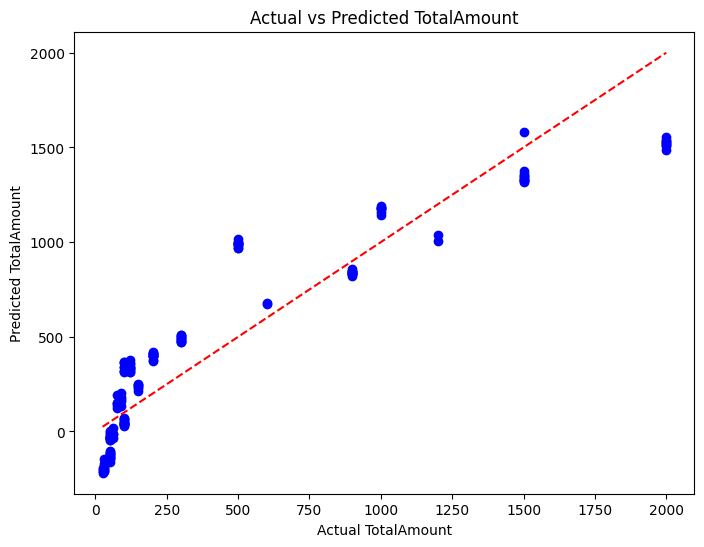

In [0]:
import matplotlib.pyplot as plt

pred_pdf = predictions.select("label", "prediction").toPandas()

plt.figure(figsize=(8,6))
plt.scatter(pred_pdf['label'], pred_pdf['prediction'], color='blue')
plt.plot([pred_pdf['label'].min(), pred_pdf['label'].max()],
         [pred_pdf['label'].min(), pred_pdf['label'].max()],
         'r--')
plt.xlabel("Actual TotalAmount")
plt.ylabel("Predicted TotalAmount")
plt.title("Actual vs Predicted TotalAmount")
plt.show()